# make interaction figures for T-B interaction
## related to Figure S10 A, C
specific aims: how does Tmem C3 ligand affect the B effector C9?

- ligand from C3
- receptor on C9
- DEG from C9 vs C8


# Setup


In [ ]:
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library("tidyverse")
quiet_library("ggplot2")
# quiet_library('nichenetr')


In [ ]:
# define file path
data_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction"
fig_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/figures"
output_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction"
ref_path <- "/home/workspace/private/reference_data/nichenet"
if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
# define a project name
proj_name <- "ALTRA_lg_TB_interaction_"


In [ ]:
# define the color palette to be used
npg_color <- c(
    "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
    "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
    "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)


# load degs list to plot gene logfc


In [ ]:
# load Tmem C3 vs rest
c3_rest_degs <- read_csv(
    file.path(
        data_path,
        "CD4T_mem_certpro_DEGs_wilcoxon_res_0.4_CLUSTER_3_Filtered_vs_Rest_py.csv"
    ),
    show_col_types = FALSE, col_select = -1
) %>% rename("genes" = "names")
c3_exprs_genes <- read_csv(
    file.path(
        data_path,
        "ALTRA_TmemC3_expressed_genes.csv"
    ),
    col_select = -1,
    show_col_types = FALSE
) %>% rename("precentage_expressed" = "props")

c3_rest_degs <- c3_rest_degs %>% left_join(c3_exprs_genes, by = "genes")


New names:
• `` -> `...1`
New names:
• `` -> `...1`


In [ ]:
data_path


[1] "/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction"

In [ ]:
# load Beff c9 vs C8
beff_c9_degs <- read_csv("/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/Bmem/Bmem_results/ALTRA_scRNA_Bmem_certPro_leiden_0_8c9vsc8_wilcoxon_sig_degs.csv",
    show_col_types = FALSE, col_select = -1
) %>% rename("genes" = "names")
c9_exprs_genes <- read_csv(
    file.path(
        data_path,
        "ALTRA_BeffC9_expressed_genes.csv"
    ),
    col_select = -1,
    show_col_types = FALSE
) %>% rename("precentage_expressed" = "props")
beff_c9_degs <- beff_c9_degs %>% full_join(c9_exprs_genes, by = "genes")


New names:
• `` -> `...1`
New names:
• `` -> `...1`


In [ ]:
beff_c9_degs %>% head()


genes,scores,logfoldchanges,pvals,pvals_adj,precentage_expressed,cell_type
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CIB1,37.97173,1.6511965,0.000000e+00,0.000000e+00,0.9536501,CD27- effector B cell_C9
IGHM,-41.82729,-3.1135962,0.000000e+00,0.000000e+00,0.5851680,CD27- effector B cell_C9
IGHD,-39.52297,-2.8024480,0.000000e+00,0.000000e+00,0.4600232,CD27- effector B cell_C9
TMSB4X,37.22413,0.6441743,2.778765e-291,2.329855e-291,1.0000000,CD27- effector B cell_C9
CD79B,-34.44152,-1.1698828,6.031199e-260,4.045487e-256,0.9003476,CD27- effector B cell_C9
S100A11,28.87198,1.6308428,2.685002e-183,1.500827e-179,0.7925840,CD27- effector B cell_C9


In [ ]:
# combine genes that are differetial in C3 or C9
tb_degs <- bind_rows(c3_rest_degs, beff_c9_degs)
tb_degs %>% head()


genes,scores,logfoldchanges,pvals,pvals_adj,direction,precentage_expressed,cell_type
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
LIMS1,173.4471,2.0587560,0,0,up,0.8456329,CD4mem_C3
FYB1,125.4221,0.9869149,0,0,up,0.9506329,CD4mem_C3
KLRB1,119.8633,1.7975423,0,0,up,0.7069620,CD4mem_C3
MAF,117.4443,1.7790763,0,0,up,0.6089241,CD4mem_C3
RPS3,-117.3739,-0.3322848,0,0,down,0.9972785,CD4mem_C3
NEAT1,116.6669,1.2802397,0,0,up,0.8745570,CD4mem_C3


In [ ]:
# load nichenet results
c3_c9_nichenet <- read_csv("/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/nichenet/ALTRA_nichenet_TmemC3_to_Beff_TmemC3_BeffectorC9vsC8.csv")


Rows: 58 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): test_ligand
dbl (5): auroc, aupr, aupr_corrected, pearson, rank

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## plot the t to b interaction


In [ ]:
c3_c9_nichenet %>% dim()


[1] 58  6

In [ ]:
c3_ligands_oi <- c(
    "CD52", "ST6GAL1", "IRAK4", "SIRPG", "SEMA4D", "PTDSS1", "ADAM10", "CALM1", "LGALS9", "LGALS1",
    "CD40LG", "CD28", "TXLNA", "CD40LG", "PTDSS1"
)


In [ ]:
c3_c9_nichenet_degs <- c3_c9_nichenet %>%
    left_join(c3_rest_degs, by = c("test_ligand" = "genes")) %>%
    filter(test_ligand %in% c3_ligands_oi) %>%
    arrange(desc(aupr_corrected)) %>%
    mutate(test_ligand = factor(test_ligand, levels = unique(test_ligand)))
c3_c9_nichenet_degs


test_ligand,auroc,aupr,aupr_corrected,pearson,rank,scores,logfoldchanges,pvals,pvals_adj,direction,precentage_expressed,cell_type
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
SEMA4D,0.5525506,0.09997165,0.04467846,0.084061609,2,26.940815,0.3807288,7.308730e-160,4.863496e-158,up,0.4768354,CD4mem_C3
CD40LG,0.5976657,0.09625693,0.04096374,0.073524682,5,9.895333,0.1378085,4.361560e-23,5.040593e-22,up,0.3630380,CD4mem_C3
ADAM10,0.5735404,0.09142839,0.03613520,0.064986935,11,23.677680,0.4797558,6.123988e-124,3.111914e-122,up,0.2817089,CD4mem_C3
CD28,0.5698105,0.09009924,0.03480605,0.049155119,17,61.003850,0.9477691,0.000000e+00,0.000000e+00,up,0.4827848,CD4mem_C3
CD52,0.5767322,0.08857771,0.03328452,0.053972313,19,33.218822,0.1581567,5.758311e-242,6.331877e-240,up,0.9927848,CD4mem_C3
LGALS9,0.5674177,0.08837163,0.03307844,0.061722781,20,21.997887,0.9086940,3.017068e-107,1.297262e-105,up,0.1454430,CD4mem_C3
SIRPG,0.5528085,0.08482667,0.02953348,0.059613003,36,26.353413,0.5525978,4.690459e-153,2.951381e-151,up,0.2752532,CD4mem_C3
LGALS1,0.5587696,0.08439639,0.02910320,0.032932296,40,-49.612330,-0.9940573,0.000000e+00,0.000000e+00,down,0.2913924,CD4mem_C3
ST6GAL1,0.5558002,0.07337758,0.01808439,-0.002965152,52,19.008339,0.3672426,1.454882e-80,4.714381e-79,up,0.2812658,CD4mem_C3


In [ ]:
c3_c9_nichenet_degs %>% pull(test_ligand)


[1] SEMA4D  CD40LG  ADAM10  CD28    CD52    LGALS9  SIRPG   LGALS1  ST6GAL1
[10] PTDSS1 
10 Levels: SEMA4D CD40LG ADAM10 CD28 CD52 LGALS9 SIRPG LGALS1 ... PTDSS1

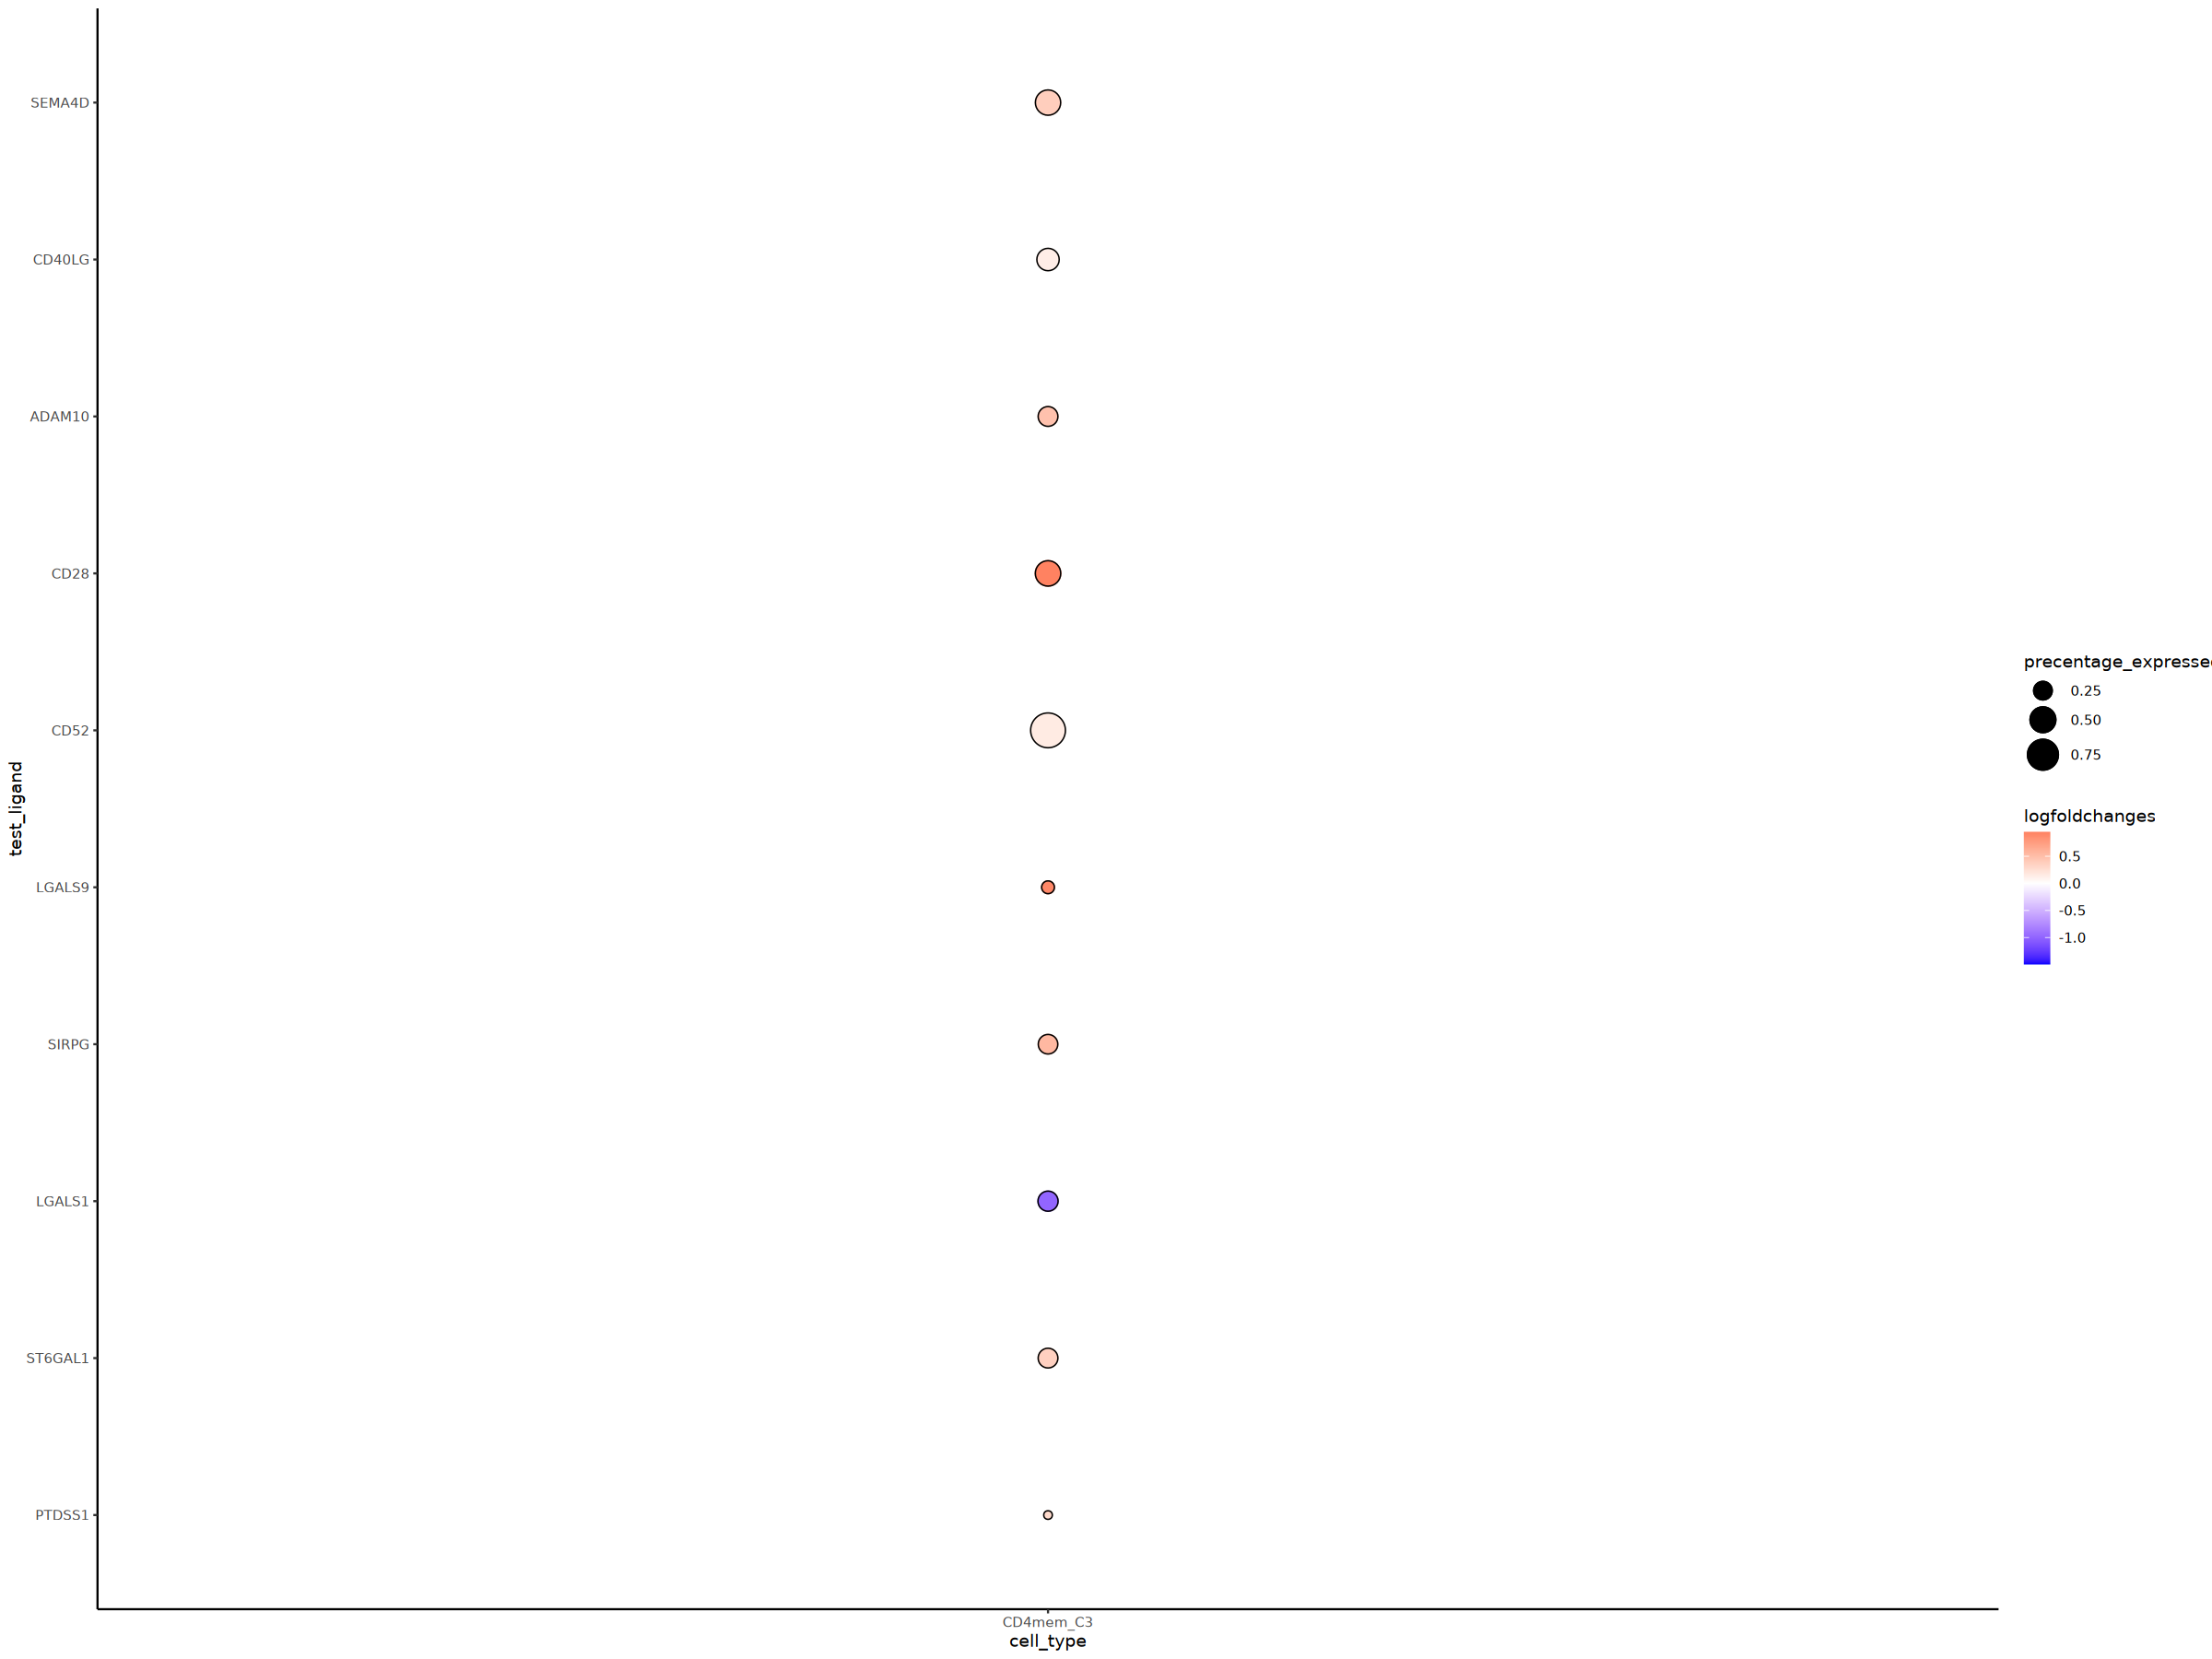

In [ ]:
# plot the ligand from C3
c3_c9_nichenet_degs %>% ggplot(aes(x = cell_type, y = test_ligand, color = logfoldchanges, size = precentage_expressed)) +
  geom_point() +
  geom_point(shape = 21, stroke = 0.5, color = "black") +
  scale_color_gradient2(
    low = "blue", # Color for low expression
    high = "red", # Color for high expression
    mid = "white", # Midpoint color
    midpoint = 0, # Midpoint value (e.g., 0 if you're working with centered data)
    limits = c(min(c3_c9_nichenet_degs$logfoldchanges) - 0.5, max(c3_c9_nichenet_degs$logfoldchanges)) # Define the limits
  ) +
  scale_y_discrete(limits = rev) +
  scale_size_continuous(range = c(2, 10)) + # Adjust size range
  # scale_color_gradient(low = "lightblue", high = "darkblue") + # Adjust color scale
  theme_classic()
ggsave(file.path(fig_path, paste0(proj_name, "c3_ligands_genes.pdf")), width = 4, height = 6)


In [ ]:
c3_c9_nichenet_degs %>% pull(test_ligand)


[1] SEMA4D  CD40LG  ADAM10  CD28    CD52    LGALS9  SIRPG   LGALS1  ST6GAL1
[10] PTDSS1 
10 Levels: SEMA4D CD40LG ADAM10 CD28 CD52 LGALS9 SIRPG LGALS1 ... PTDSS1

In [ ]:
# ligand_receptor pair
b_receptor <- c("CD72", "CD40", "TSPAN14", "CD86", "SIGLEC10", "SLC1A5", "CD47", "PTPRC", "CD22", "JMJD6")
lig_rep <- tibble(
    "ligand" = c3_c9_nichenet_degs$test_ligand,
    receptor = b_receptor
)
lig_rep


ligand,receptor
<fct>,<chr>
SEMA4D,CD72
CD40LG,CD40
ADAM10,TSPAN14
CD28,CD86
CD52,SIGLEC10
LGALS9,SLC1A5
SIRPG,CD47
LGALS1,PTPRC
ST6GAL1,CD22


In [ ]:
beff_c9_recp <- beff_c9_degs %>%
    filter(genes %in% lig_rep$receptor) %>%
    mutate(
        logfoldchanges = replace_na(logfoldchanges, 0),
        genes = factor(genes, levels = lig_rep$receptor)
    )
beff_c9_recp


genes,scores,logfoldchanges,pvals,pvals_adj,precentage_expressed,cell_type
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CD86,20.263313,2.9595096,2.710948e-91,2.020440e-88,0.3406721,CD27- effector B cell_C9
CD72,-18.670970,-0.8945888,8.528916e-78,4.400658e-75,0.6454229,CD27- effector B cell_C9
CD40,-9.008552,-0.8411940,2.087966e-19,2.006481e-17,0.2723059,CD27- effector B cell_C9
CD22,8.938454,0.5498856,3.946534e-19,3.728419e-17,0.6616454,CD27- effector B cell_C9
PTPRC,7.616193,0.2582190,2.612662e-14,1.795563e-12,0.9640788,CD27- effector B cell_C9
SLC1A5,6.456781,1.5731324,1.069535e-10,5.426637e-09,0.1587486,CD27- effector B cell_C9
SIGLEC10,4.742540,0.5944602,2.110554e-06,6.529866e-05,0.2155272,CD27- effector B cell_C9
CD47,NA,0.0000000,NA,NA,0.6685979,CD27- effector B cell_C9
JMJD6,NA,0.0000000,NA,NA,0.1054461,CD27- effector B cell_C9


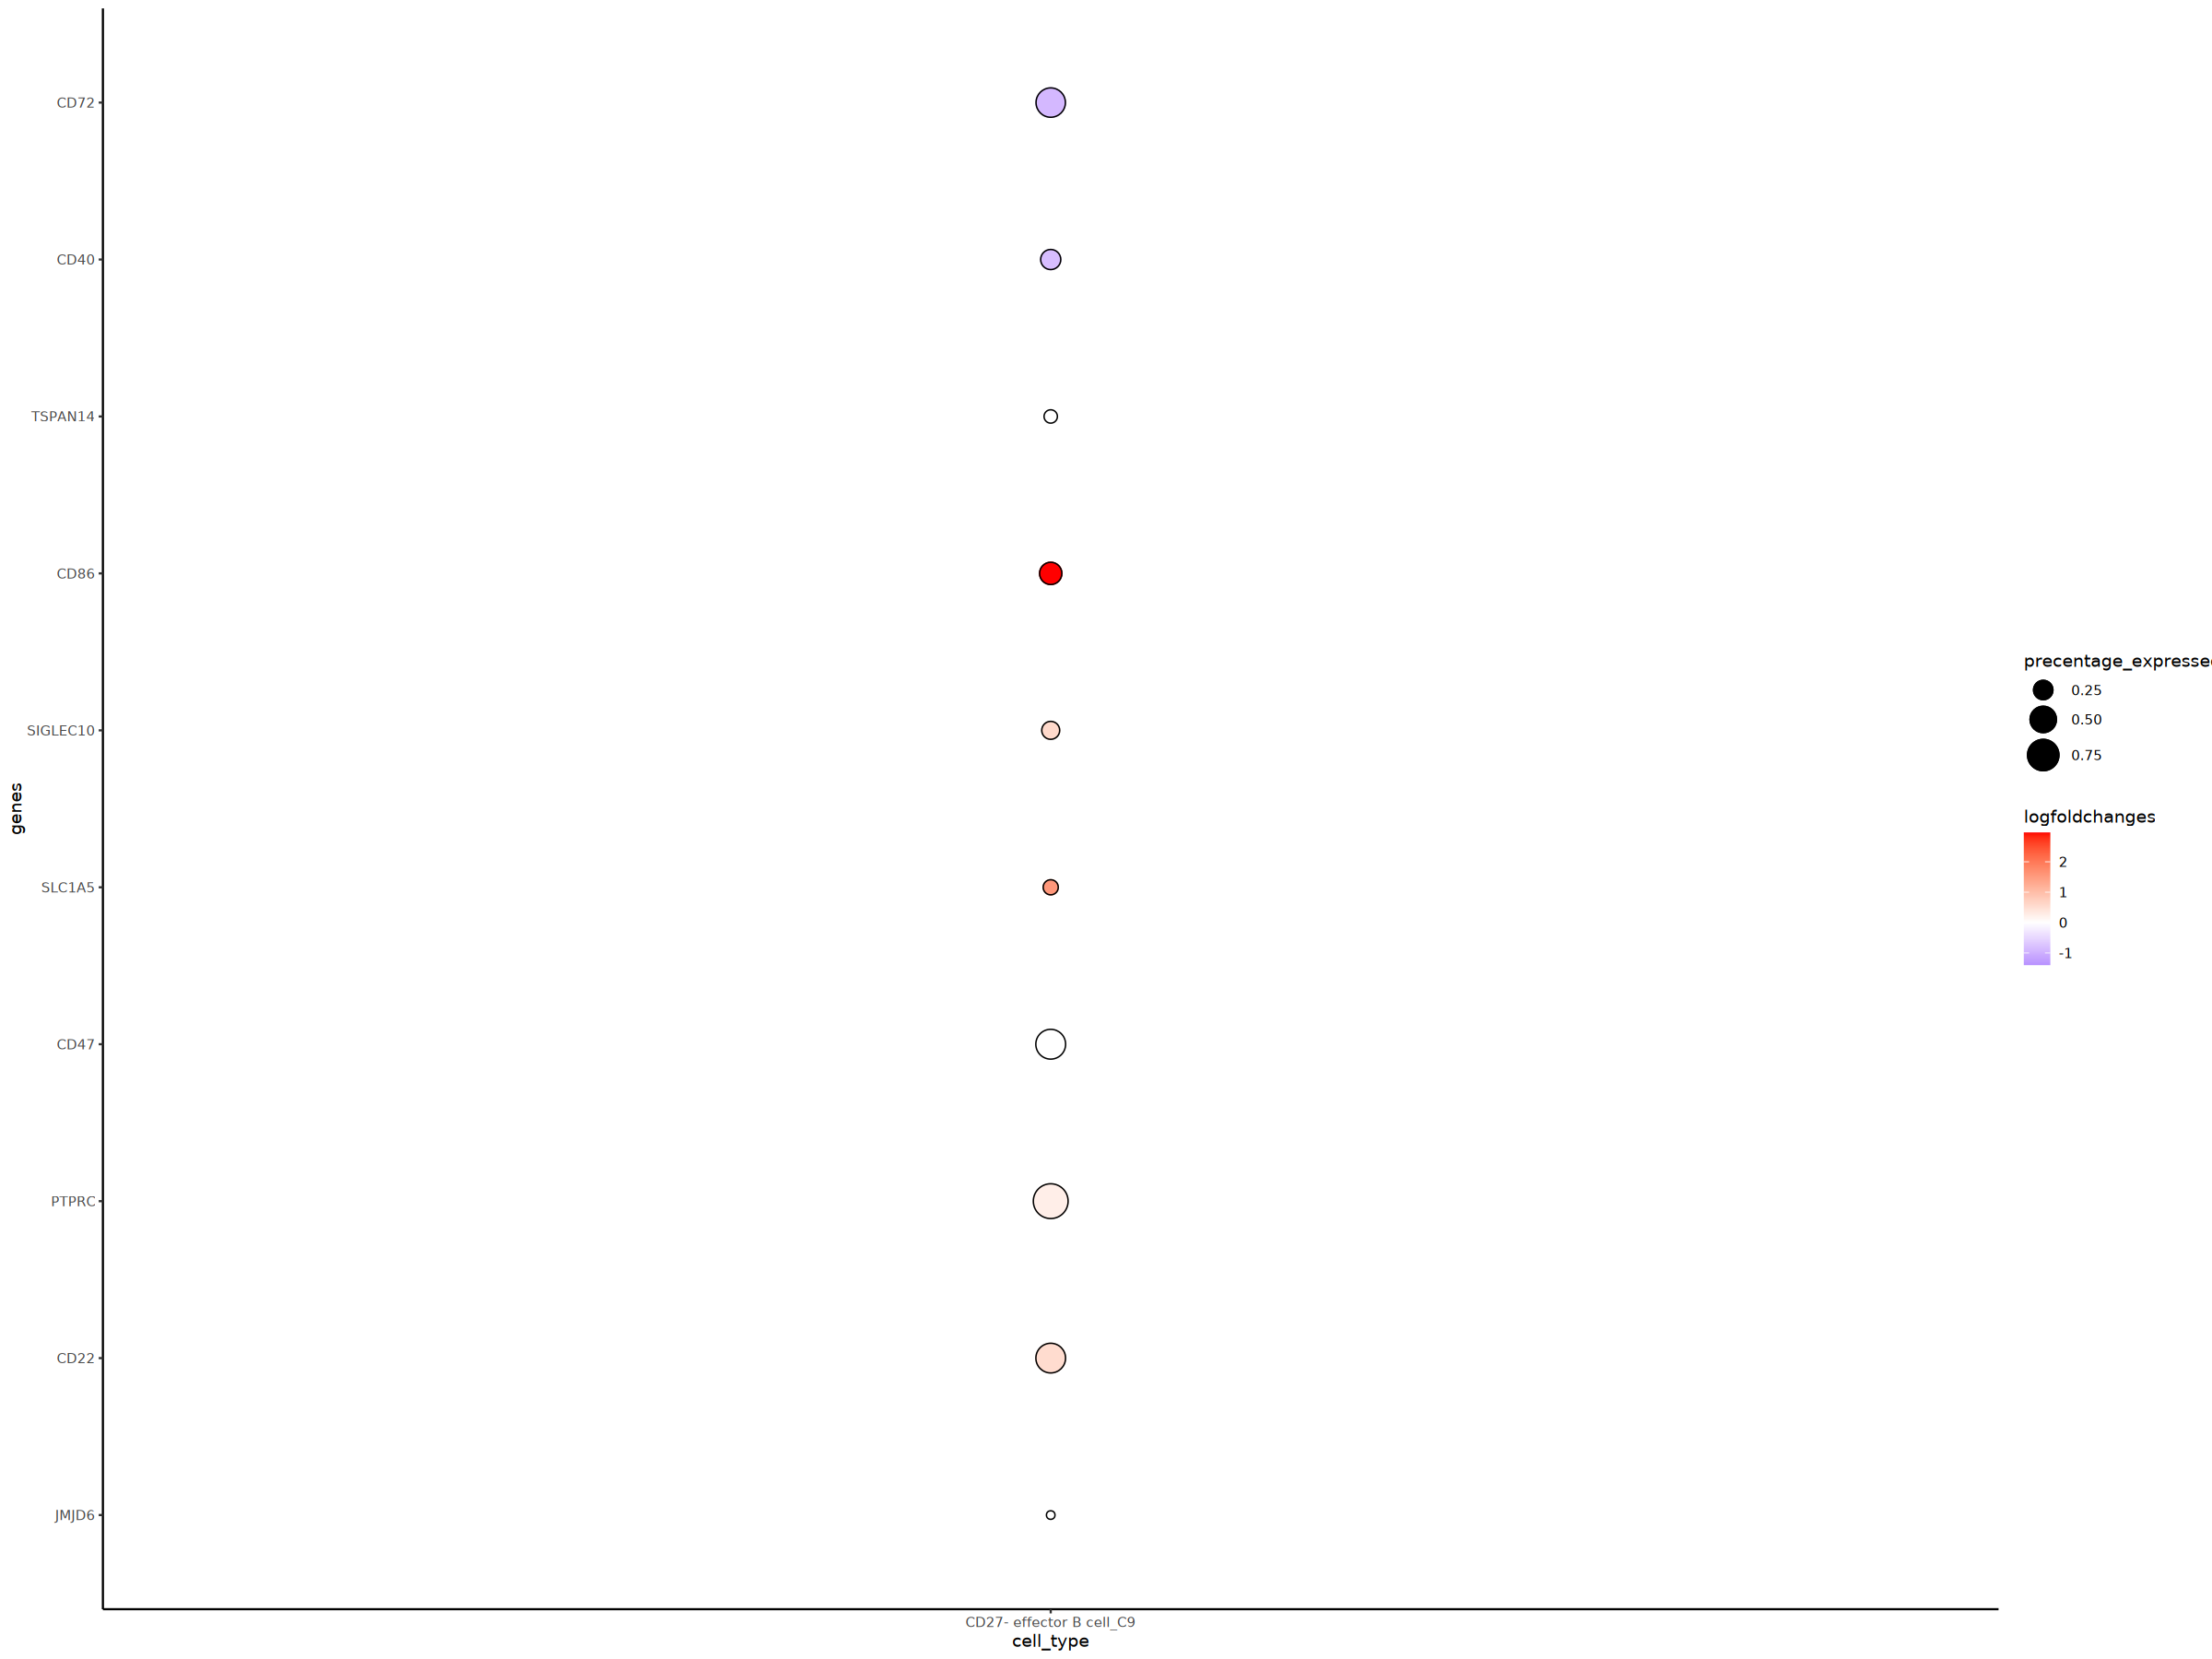

In [ ]:
# plot the receptor in B cells

beff_c9_recp %>% ggplot(aes(x = cell_type, y = genes, color = logfoldchanges, size = precentage_expressed)) +
  geom_point() +
  geom_point(shape = 21, stroke = 0.5, color = "black") +
  scale_color_gradient2(
    low = "blue", # Color for low expression
    high = "red", # Color for high expression
    mid = "white", # Midpoint color
    midpoint = 0, # Midpoint value (e.g., 0 if you're working with centered data)
    limits = c(min(beff_c9_recp$logfoldchanges) - 0.5, max(beff_c9_recp$logfoldchanges)) # Define the limits
  ) +
  scale_y_discrete(limits = rev) +
  scale_size_continuous(range = c(2, 10)) + # Adjust size range
  # scale_color_gradient(low = "lightblue", high = "darkblue") + # Adjust color scale
  theme_classic()
ggsave(file.path(fig_path, paste0(proj_name, "c9_receptor_genes.pdf")), width = 4, height = 6)


## plot the b to t interaction


In [ ]:
# load nichenet results
c9_c3_nichenet <- read_csv("/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/nichenet/ALTRA_Nichenet_Beff_to_TmemC3nichenet_results.csv",
    show_col_types = FALSE
)
c9_c3_nichenet %>% head(10)


test_ligand,auroc,aupr,aupr_corrected,pearson,rank
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TGFB1,0.6305288,0.08839315,0.04780546,0.13523751,1
IL7,0.6010330,0.08297472,0.04238702,0.08593314,2
HLA-A,0.5676897,0.07712304,0.03653534,0.08577345,3
CD86,0.5555147,0.07525636,0.03466867,0.08722779,4
ZDHHC5,0.5765792,0.07100364,0.03041594,0.05414971,5
HLA-DQB1,0.5509734,0.07072530,0.03013761,0.04755923,6
B2M,0.5613424,0.07024581,0.02965812,0.06418504,7
BACE2,0.5910044,0.07013349,0.02954580,0.07868423,8
S100A8,0.5664476,0.06989670,0.02930900,0.06935464,9


In [ ]:
bc9_tc3_lig_rep <- tibble(
    "c9_ligands" = c(
        "CCL5", "IL7", "CD86",
        "HLA-DQB1", "S100A8", "HLA-DRB1", "CD48", "CD72"
    ),
    "c3_receptor" = c(
        "CXCR3", "IL7R", "CD28",
        "CD4", "ITGB2", "CD4", "CD2", "CD5"
    )
)
bc9_tc3_lig_rep <- bc9_tc3_lig_rep %>%
    left_join(c9_c3_nichenet, by = c("c9_ligands" = "test_ligand")) %>%
    arrange(rank) %>%
    mutate(c9_ligands = factor(c9_ligands, unique(bc9_tc3_lig_rep$c9_ligands)))
bc9_tc3_lig_rep


c9_ligands,c3_receptor,auroc,aupr,aupr_corrected,pearson,rank
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
IL7,IL7R,0.6010330,0.08297472,0.04238702,0.08593314,2
CD86,CD28,0.5555147,0.07525636,0.03466867,0.08722779,4
HLA-DQB1,CD4,0.5509734,0.07072530,0.03013761,0.04755923,6
S100A8,ITGB2,0.5664476,0.06989670,0.02930900,0.06935464,9
CCL5,CXCR3,0.5685706,0.06675958,0.02617188,0.05075099,13
CD72,CD5,0.5705056,0.06594668,0.02535898,0.05204959,15
HLA-DRB1,CD4,0.5429734,0.06343952,0.02285183,0.03818731,20
CD48,CD2,0.5683982,0.06201951,0.02143182,0.03376516,28


In [ ]:
bc9_tc3_lig_rep$c9_ligands %>% paste(sep = '", "')


[1] "IL7"      "CD86"     "HLA-DQB1" "S100A8"   "CCL5"     "CD72"     "HLA-DRB1"
[8] "CD48"

c9_ligands,c3_receptor,auroc,aupr,aupr_corrected,pearson,rank,scores,logfoldchanges,pvals,pvals_adj,precentage_expressed,cell_type
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
IL7,IL7R,0.6010330,0.08297472,0.04238702,0.08593314,2,NA,0.0000000,NA,NA,0.1158749,CD27- effector B cell_C9
CD86,CD28,0.5555147,0.07525636,0.03466867,0.08722779,4,20.26331,2.9595096,2.710948e-91,2.020440e-88,0.3406721,CD27- effector B cell_C9
HLA-DQB1,CD4,0.5509734,0.07072530,0.03013761,0.04755923,6,16.29973,0.4365421,9.912355e-60,3.259221e-57,0.9884125,CD27- effector B cell_C9
S100A8,ITGB2,0.5664476,0.06989670,0.02930900,0.06935464,9,NA,0.0000000,NA,NA,0.1853998,CD27- effector B cell_C9
CCL5,CXCR3,0.5685706,0.06675958,0.02617188,0.05075099,13,NA,0.0000000,NA,NA,0.1054461,CD27- effector B cell_C9
CD72,CD5,0.5705056,0.06594668,0.02535898,0.05204959,15,-18.67097,-0.8945888,8.528916e-78,4.400658e-75,0.6454229,CD27- effector B cell_C9


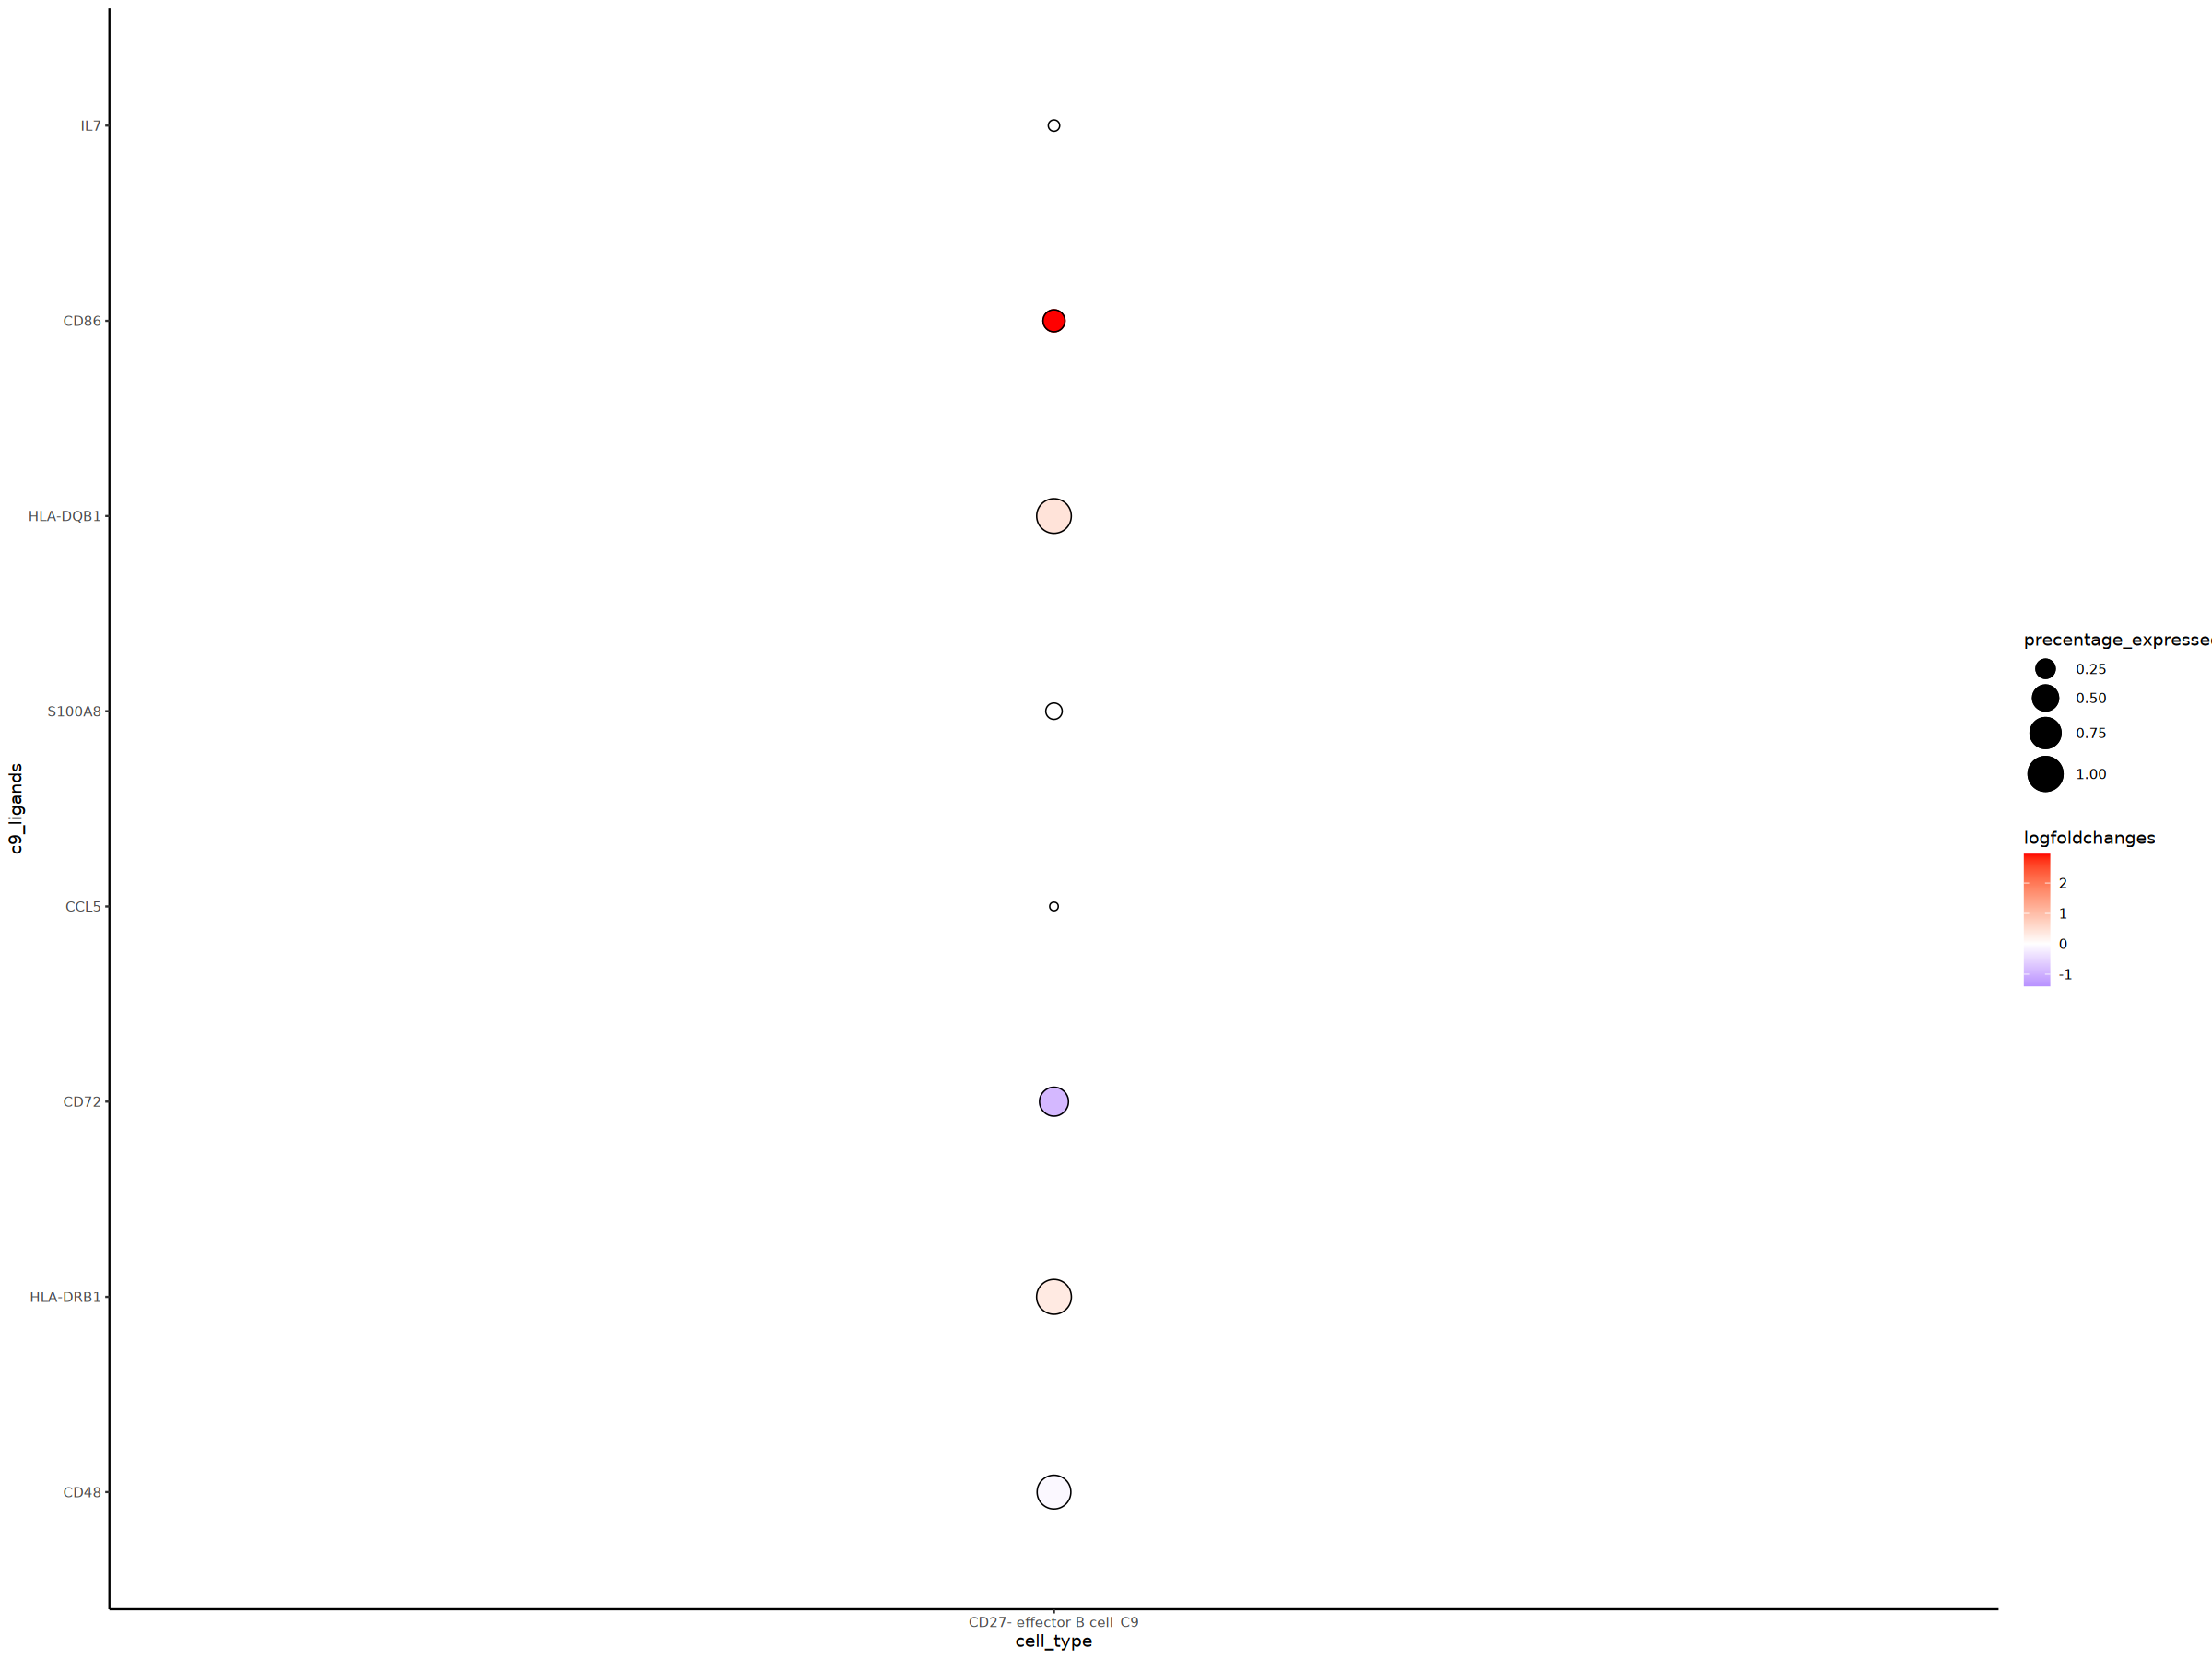

In [ ]:
bc9_lig_degs <- bc9_tc3_lig_rep %>%
  left_join(beff_c9_degs, by = c("c9_ligands" = "genes")) %>%
  mutate(logfoldchanges = replace_na(logfoldchanges, 0)) %>%
  mutate(c9_ligands = factor(c9_ligands, unique(bc9_tc3_lig_rep$c9_ligands)))
bc9_lig_degs %>% head()
# plot the ligand from C3
bc9_lig_degs %>% ggplot(aes(x = cell_type, y = c9_ligands, color = logfoldchanges, size = precentage_expressed)) +
  geom_point() +
  geom_point(shape = 21, stroke = 0.5, color = "black") +
  scale_color_gradient2(
    low = "blue", # Color for low expression
    high = "red", # Color for high expression
    mid = "white", # Midpoint color
    midpoint = 0, # Midpoint value (e.g., 0 if you're working with centered data)
    limits = c(min(bc9_lig_degs$logfoldchanges - 0.5), max(bc9_lig_degs$logfoldchanges)) # Define the limits
  ) +
  scale_y_discrete(limits = rev) +
  scale_size_continuous(range = c(2, 10)) + # Adjust size range
  # scale_color_gradient(low = "lightblue", high = "darkblue") + # Adjust color scale
  theme_classic()
ggsave(file.path(fig_path, paste0(proj_name, "c9_ligands_genes.pdf")), width = 4, height = 6 * 0.8)


In [ ]:
tc3_recp_degs


c9_ligands,c3_receptor,auroc,aupr,aupr_corrected,pearson,rank,scores,logfoldchanges,pvals,pvals_adj,direction,precentage_expressed,cell_type
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
IL7,IL7R,0.6010330,0.08297472,0.04238702,0.08593314,2,-90.040100,-0.76387525,0.000000e+00,0.000000e+00,down,0.8875949,CD4mem_C3
CD86,CD28,0.5555147,0.07525636,0.03466867,0.08722779,4,61.003850,0.94776910,0.000000e+00,0.000000e+00,up,0.4827848,CD4mem_C3
HLA-DQB1,CD4,0.5509734,0.07072530,0.03013761,0.04755923,6,21.594568,0.32729350,2.020215e-103,8.364687e-102,up,0.4026582,CD4mem_C3
S100A8,ITGB2,0.5664476,0.06989670,0.02930900,0.06935464,9,-2.967188,-0.01680003,3.005368e-03,1.386247e-02,down,0.6446203,CD4mem_C3
CCL5,CXCR3,0.5685706,0.06675958,0.02617188,0.05075099,13,-13.145358,-0.59443030,1.809468e-39,3.064946e-38,down,0.1203797,CD4mem_C3
CD72,CD5,0.5705056,0.06594668,0.02535898,0.05204959,15,19.562567,0.34129667,3.224285e-85,1.095603e-83,up,0.3278481,CD4mem_C3
HLA-DRB1,CD4,0.5429734,0.06343952,0.02285183,0.03818731,20,21.594568,0.32729350,2.020215e-103,8.364687e-102,up,0.4026582,CD4mem_C3
CD48,CD2,0.5683982,0.06201951,0.02143182,0.03376516,28,37.624863,0.29712784,8.432717e-293,1.245888e-292,up,0.9332278,CD4mem_C3


c9_ligands,c3_receptor,auroc,aupr,aupr_corrected,pearson,rank,scores,logfoldchanges,pvals,pvals_adj,direction,precentage_expressed,cell_type
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
IL7,IL7R,0.6010330,0.08297472,0.04238702,0.08593314,2,-90.040100,-0.76387525,0.000000e+00,0.000000e+00,down,0.8875949,CD4mem_C3
CD86,CD28,0.5555147,0.07525636,0.03466867,0.08722779,4,61.003850,0.94776910,0.000000e+00,0.000000e+00,up,0.4827848,CD4mem_C3
HLA-DQB1,CD4,0.5509734,0.07072530,0.03013761,0.04755923,6,21.594568,0.32729350,2.020215e-103,8.364687e-102,up,0.4026582,CD4mem_C3
S100A8,ITGB2,0.5664476,0.06989670,0.02930900,0.06935464,9,-2.967188,-0.01680003,3.005368e-03,1.386247e-02,down,0.6446203,CD4mem_C3
CCL5,CXCR3,0.5685706,0.06675958,0.02617188,0.05075099,13,-13.145358,-0.59443030,1.809468e-39,3.064946e-38,down,0.1203797,CD4mem_C3
CD72,CD5,0.5705056,0.06594668,0.02535898,0.05204959,15,19.562567,0.34129667,3.224285e-85,1.095603e-83,up,0.3278481,CD4mem_C3


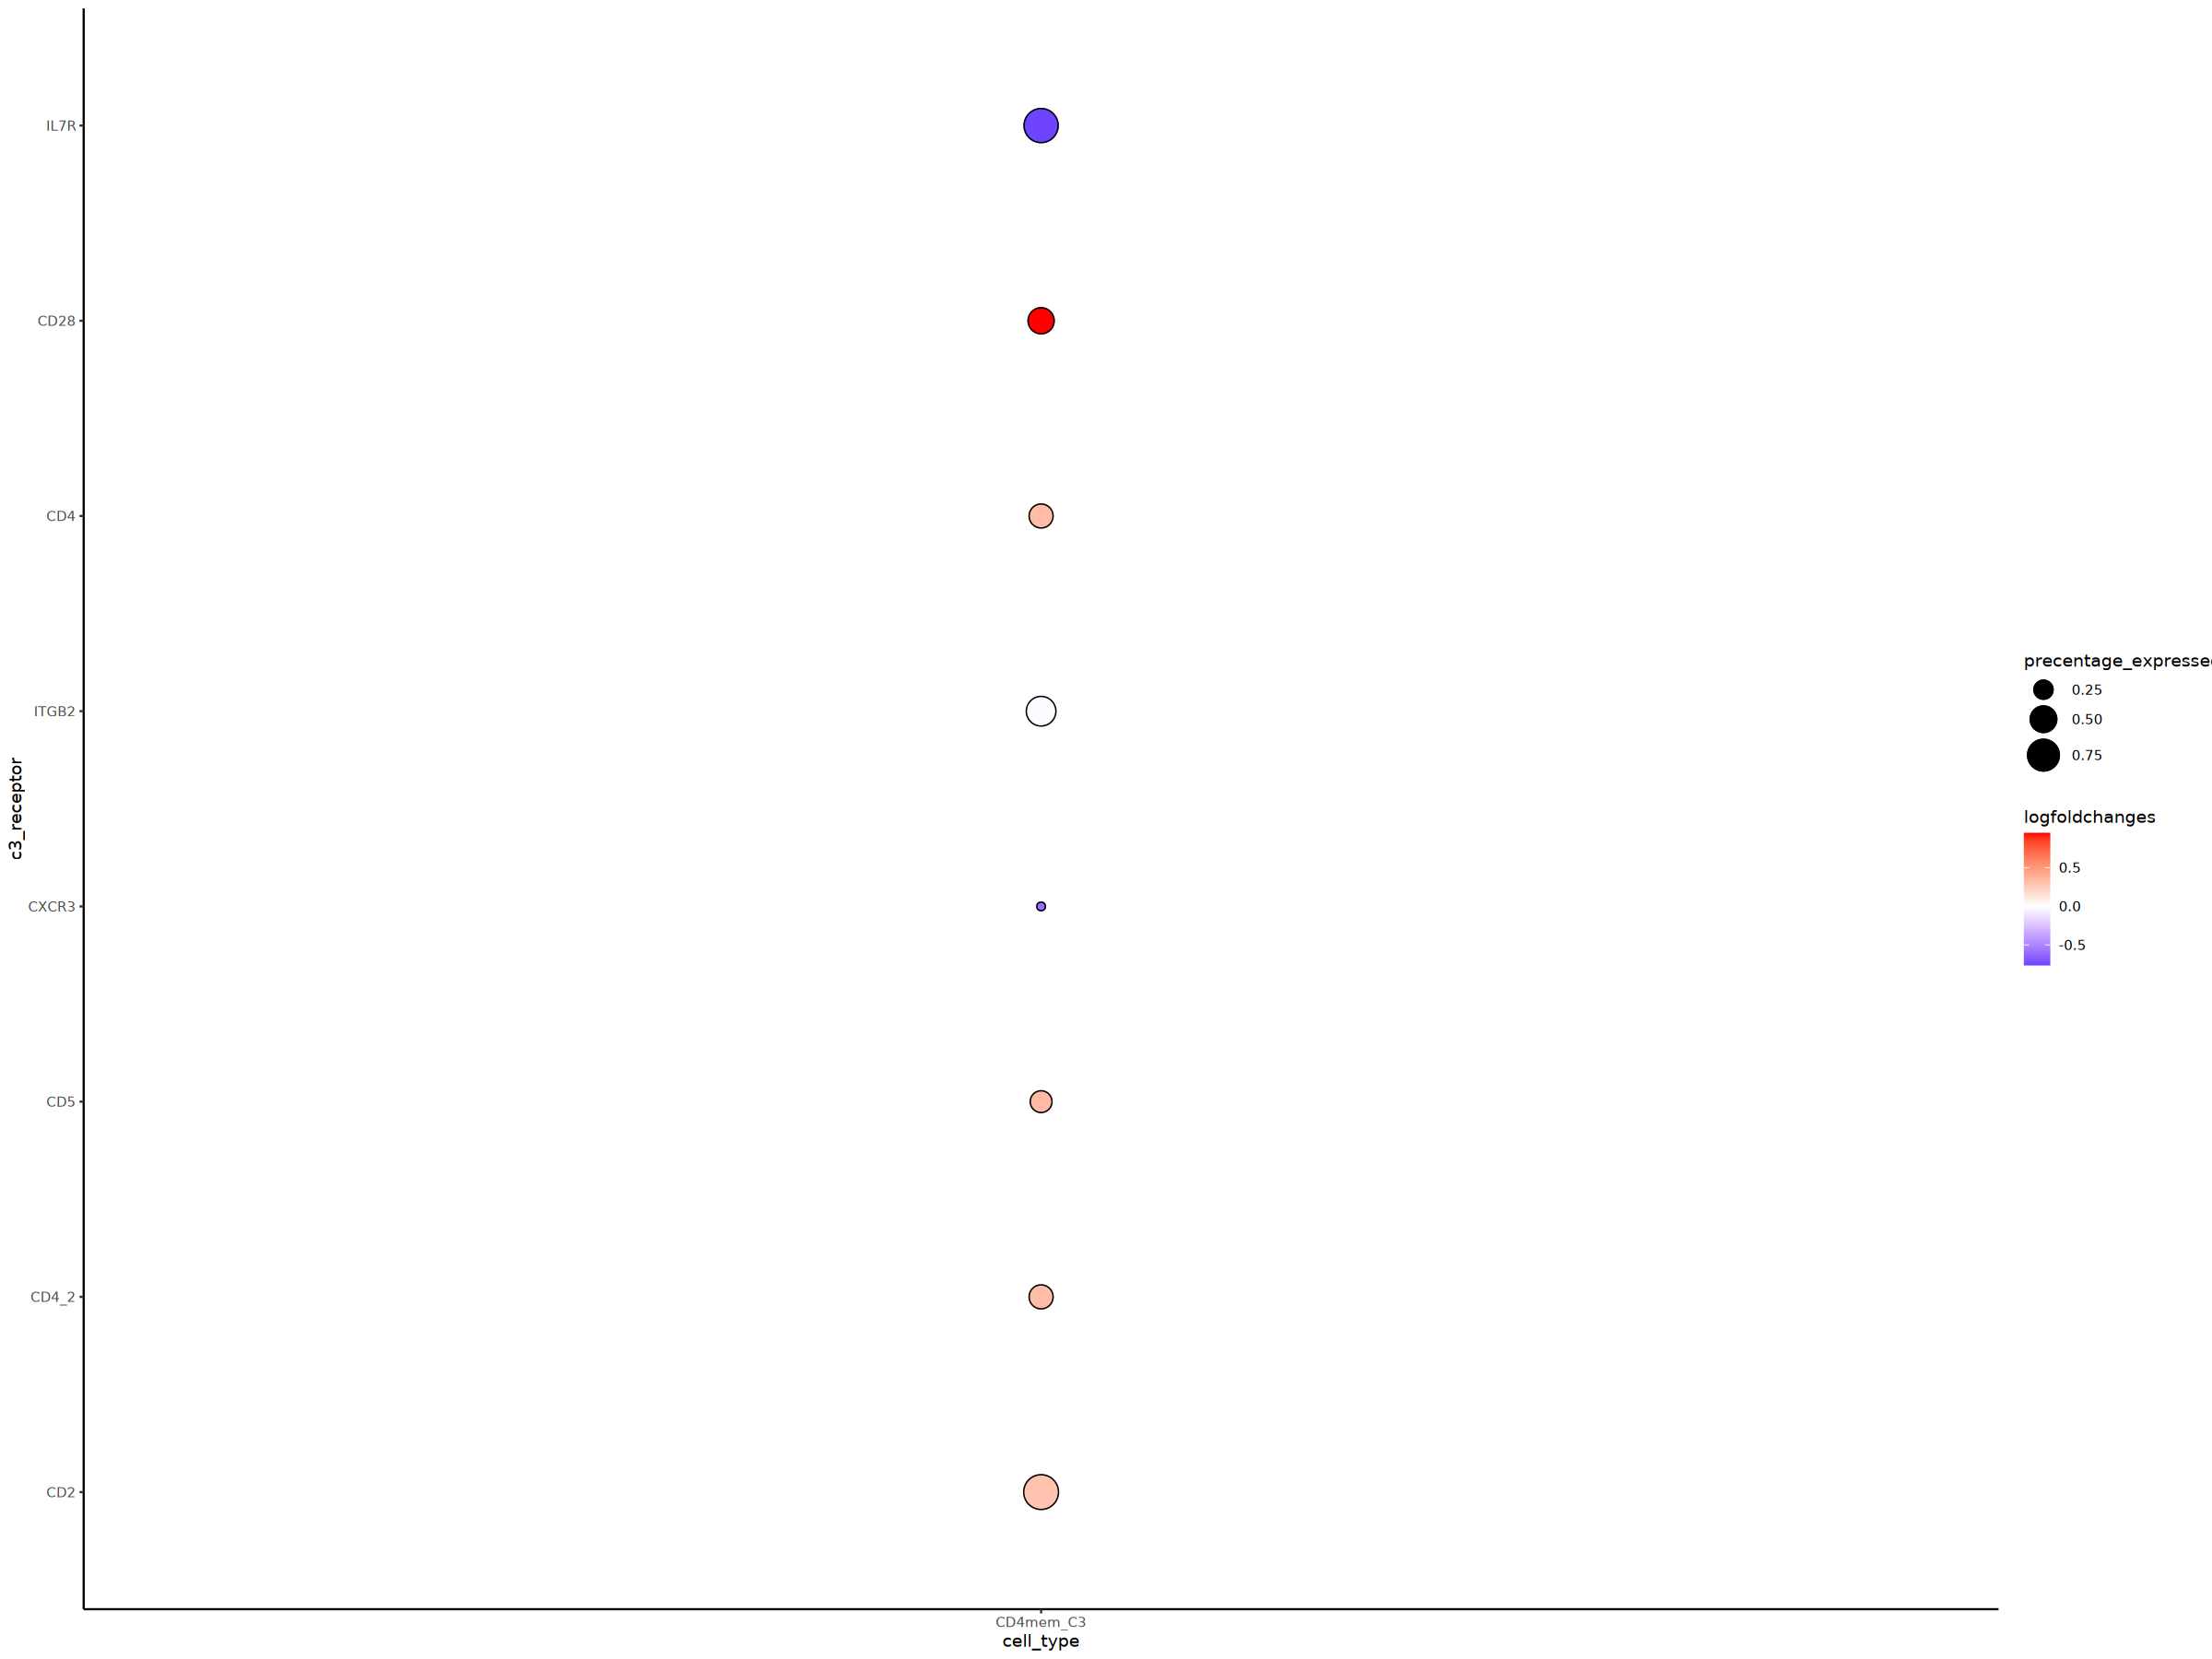

In [ ]:
tc3_recp_degs <- bc9_tc3_lig_rep %>%
  left_join(c3_rest_degs, by = c("c3_receptor" = "genes")) %>%
  mutate(logfoldchanges = replace_na(logfoldchanges, 0)) %>%
  mutate(c3_receptor = if_else(c9_ligands == "HLA-DRB1", "CD4_2", c3_receptor))
tc3_recp_degs <- tc3_recp_degs %>% mutate(c3_receptor = factor(c3_receptor, levels = unique(tc3_recp_degs$c3_receptor)))

tc3_recp_degs %>% head()
# plot the ligand from C3
tc3_recp_degs %>% ggplot(aes(x = cell_type, y = c3_receptor, color = logfoldchanges, size = precentage_expressed)) +
  geom_point() +
  geom_point(shape = 21, stroke = 0.5, color = "black") +
  scale_color_gradient2(
    low = "blue", # Color for low expression
    high = "red", # Color for high expression
    mid = "white", # Midpoint color
    midpoint = 0, # Midpoint value (e.g., 0 if you're working with centered data)
    limits = c(min(tc3_recp_degs$logfoldchanges), max(tc3_recp_degs$logfoldchanges)) # Define the limits
  ) +
  scale_y_discrete(limits = rev) +
  scale_size_continuous(range = c(2, 10)) + # Adjust size range
  # scale_color_gradient(low = "lightblue", high = "darkblue") + # Adjust color scale
  theme_classic()
ggsave(file.path(fig_path, paste0(proj_name, "c3_recptor_genes.pdf")), width = 4, height = 6 * 0.8)


## output table S34


In [ ]:
# load nichenet results
c3_c9_nichenet <- read_csv("/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/nichenet/ALTRA_nichenet_TmemC3_to_Beff_TmemC3_BeffectorC9vsC8.csv",
    show_col_types = FALSE
) %>% mutate(direction = "CD4memC3 to BeffC9")
# load nichenet results
c9_c3_nichenet <- read_csv("/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/nichenet/ALTRA_Nichenet_Beff_to_TmemC3nichenet_results.csv",
    show_col_types = FALSE
) %>% mutate(direction = "BeffC9 to CD4memC3")


In [ ]:
table_s34 <- bind_rows(c3_c9_nichenet, c9_c3_nichenet)
table_s34 %>% head()


test_ligand,auroc,aupr,aupr_corrected,pearson,rank,direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
TGFB1,0.6303384,0.11508779,0.05979460,0.14644095,1,CD4memC3 to BeffC9
SEMA4D,0.5525506,0.09997165,0.04467846,0.08406161,2,CD4memC3 to BeffC9
ADAM17,0.5902748,0.09832151,0.04302832,0.08448872,3,CD4memC3 to BeffC9
HLA-C,0.5895120,0.09649922,0.04120603,0.08045909,4,CD4memC3 to BeffC9
CD40LG,0.5976657,0.09625693,0.04096374,0.07352468,5,CD4memC3 to BeffC9
CD7,0.5709453,0.09602756,0.04073437,0.06591476,6,CD4memC3 to BeffC9


In [ ]:
table_s34 %>% write_csv(file.path(output_path, "TableS34_Nichenet_results.csv"))
